In [1]:
%load_ext rpy2.ipython


In [2]:
%%R
# List of required packages
required_packages <- c(
  "sesame", "conumee2", "IlluminaHumanMethylation450kanno.ilmn12.hg19",
  "IlluminaHumanMethylationEPICanno.ilm10b4.hg19", "BiocParallel", 
  "dplyr", "GenomicRanges"
)

# Check if packages are installed before loading
for (pkg in required_packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    BiocManager::install(pkg, force = TRUE)
  }
  library(pkg, character.only = TRUE)
}

# Register parallel backend with 7 CPU cores
if (.Platform$OS.type == "windows") {
  register(SnowParam(7))  # Windows-friendly parallel processing
} else {
  register(MulticoreParam(7))  # Unix/Linux systems
}

cat("\n✅ All necessary packages installed and loaded successfully! 🚀\n")


✅ All necessary packages installed and loaded successfully! 🚀


Loading required package: sesameData
Loading required package: ExperimentHub
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, setdiff, sort, table,
    tapply, union, unique, unsplit, which.max, which.min

Loading required package: AnnotationHub
Loading required package: BiocFileCache
Loading required package: dbplyr
Loading sesameData.

----------------------------------------------------------
| SEnsible Step-wise Analysis of DNA MEthylation (SeSAMe)
| ------------------------------------------------------

In [ ]:
%%R
##############################################################
# Copy Number Variation (CNV) Analysis using SeSAMe & Conumee2
# Author: Nijat
# Last Modified: 2025
##############################################################

### 1. Install & Load Necessary Packages

if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager")
}

if (!requireNamespace("devtools", quietly = TRUE)) {
  install.packages("devtools")
}

# Install or update necessary Bioconductor packages
BiocManager::install(c(
  "sesame", "conumee2",
  "IlluminaHumanMethylation450kanno.ilmn12.hg19",
  "IlluminaHumanMethylationEPICanno.ilm10b4.hg19",
  "BiocParallel", "dplyr", "GenomicRanges"
), force = TRUE)  

# Install the latest Conumee2 from GitHub
devtools::install_github("hovestadtlab/conumee2", subdir = "conumee2", force = TRUE)

# List of required packages
required_packages <- c(
  "sesame", "conumee2", "IlluminaHumanMethylation450kanno.ilmn12.hg19",
  "IlluminaHumanMethylationEPICanno.ilm10b4.hg19", "BiocParallel", 
  "dplyr", "GenomicRanges"
)

# Check if packages are installed before loading
for (pkg in required_packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    BiocManager::install(pkg, force = TRUE)
  }
  library(pkg, character.only = TRUE)
}

# Register parallel backend with 7 CPU cores
if (.Platform$OS.type == "windows") {
  register(SnowParam(7))  # Windows-friendly parallel processing
} else {
  register(MulticoreParam(7))  # Unix/Linux systems
}

cat("\n✅ All necessary packages installed and loaded successfully! 🚀\n")

#################################################
### 2. Define Paths & Ensure Results Directories
#################################################
idatPath_cases    <- "/Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/idat_file"
idatPath_controls <- "/Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/control_files"
analysisPath      <- "/Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/CNV_final_results"

sample_sheet_cases    <- "/Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/Sample_Sheet.csv"
sample_sheet_controls <- "/Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/Control_Sample_Sheet.csv"

# Create the main analysis directory if it doesn't exist
if (!dir.exists(analysisPath)) {
  dir.create(analysisPath, recursive = TRUE)
}

# Create a subdirectory for RDS outputs
rdsPath <- file.path(analysisPath, "rds_files")
if (!dir.exists(rdsPath)) {
  dir.create(rdsPath, recursive = TRUE)
}

# Create a subdirectory for CNV figures
cnv_figures <- file.path(analysisPath, "cnv_figures")
if (!dir.exists(cnv_figures)) {
  dir.create(cnv_figures, recursive = TRUE)
}

################################################################
### 3. Load & Clean Sample Sheets (Cases & Controls), Then Save
################################################################
clean_sample_sheet <- function(sample_sheet) {
  cat("\n🔍 Loading and cleaning sample sheet:", sample_sheet, "\n")
  
  targets <- read.csv(sample_sheet, stringsAsFactors = FALSE, skip = 0)
  
  # Check for required columns
  if (!all(c("Sentrix_ID", "Sentrix_Position", "Sample_Name") %in% colnames(targets))) {
    stop("🚨 Missing required columns! Please include 'Sentrix_ID', 'Sentrix_Position', and 'Sample_Name'.")
  }
  
  # Remove duplicates, keep only the first occurrence per Sample_Name
  targets <- targets %>%
    distinct() %>%
    group_by(Sample_Name) %>%
    slice(1) %>%
    ungroup()
  
  cat("\n✅ Cleaning complete! Number of samples:", nrow(targets), "\n")
  return(targets)
}

cat("\n🗂 Loading and cleaning case samples...\n")
targets_cases <- clean_sample_sheet(sample_sheet_cases)
saveRDS(targets_cases, file.path(rdsPath, "targets_cases.rds"))

cat("\n🗂 Loading and cleaning control samples...\n")
targets_controls <- clean_sample_sheet(sample_sheet_controls)
saveRDS(targets_controls, file.path(rdsPath, "targets_controls.rds"))

###################################################################
### 4. Read & Preprocess IDAT Files Using SeSAMe, Then Extract Data
###################################################################
cat("\n📂 Loading IDAT files using SeSAMe...\n")

# Preprocess using the 'QCDPB' pipeline
sdfs.q <- openSesame(
  idatPath_cases,
  prep = "QCDPB",
  BPPARAM = MulticoreParam(7),
  func = NULL
)

sdfs.c <- openSesame(
  idatPath_controls,
  prep = "QCDPB",
  BPPARAM = MulticoreParam(7),
  func = NULL
)

cat("\n✅ IDAT files successfully loaded.\n")

# Extract total intensities and load into Conumee2
data.q <- CNV.load(do.call(cbind, lapply(sdfs.q, totalIntensities)))
data.c <- CNV.load(do.call(cbind, lapply(sdfs.c, totalIntensities)))

cat("\n✅ Total intensities extracted.\n")

# Save intermediate data
saveRDS(sdfs.q, file.path(rdsPath, "sdfs_q.rds"))
saveRDS(sdfs.c, file.path(rdsPath, "sdfs_c.rds"))
saveRDS(data.q, file.path(rdsPath, "data_q.rds"))
saveRDS(data.c, file.path(rdsPath, "data_c.rds"))

#########################################################
### 5. Define CNV Annotations (Exclude & Custom Detail Regions)
#########################################################
cat("\n📌 Loading CNV annotations...\n")

# Load built-in exclude regions from conumee2
data(exclude_regions)
data(detail_regions)  # example detail regions for hg19
detail_regions
# data(detail_regions.hg38)  # detail regions for hg38 (only for EPICv2)

anno <- CNV.create_anno(array_type = c("450k", "EPICv2"), exclude_regions = exclude_regions, detail_regions = detail_regions)  

cat("\n✅ CNV annotations defined.\n")
# Save annotation data
saveRDS(anno, file.path(rdsPath, "annotation_object.rds"))

##############################################
### 6. Main CNV Analysis Pipeline
##############################################
cat("\n🚀 Running CNV analysis...\n")

# 6.1 Normalize query samples using control samples
cnv_result_fit <- CNV.fit(data.q, data.c, anno)
saveRDS(cnv_result_fit, file = file.path(rdsPath, "cnv_result_fit.rds"))

# 6.2 Perform genomic binning
cnv_result_bin <- CNV.bin(cnv_result_fit)
saveRDS(cnv_result_bin, file = file.path(rdsPath, "cnv_result_bin.rds"))

# 6.3 Analyze detail regions (optional but important for our analysis)
cnv_result_detail <- CNV.detail(cnv_result_bin)
saveRDS(cnv_result_detail, file = file.path(rdsPath, "cnv_result_detail.rds"))

# 6.4 Perform CNV segmentation
cnv_result_segment <- CNV.segment(cnv_result_detail)
saveRDS(cnv_result_segment, file = file.path(rdsPath, "cnv_result_segment.rds"))

# 6.5 Detect focal CNVs (optional but could be importnat for our anlysis)
cnv_result_focal <- CNV.focal(cnv_result_segment)
saveRDS(cnv_result_focal, file = file.path(rdsPath, "cnv_result_focal.rds"))

cat("\n✅ CNV analysis complete!\n")



In [3]:
%%R
# Load the RDS file
detail <- readRDS("/Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/CNV_final_results/rds_files/cnv_result_detail.rds")
segment <- readRDS("/Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/CNV_final_results/rds_files/cnv_result_segment.rds")


6042316060_R01C01


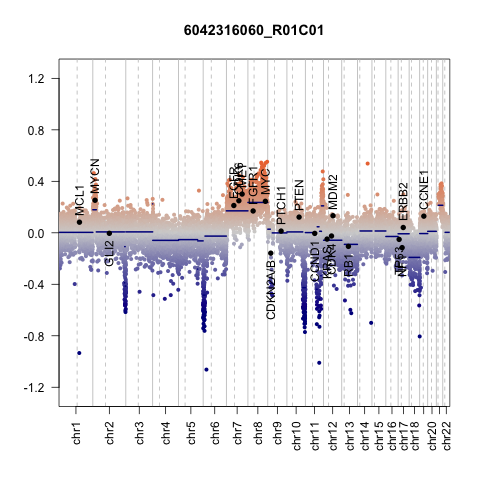

In [4]:
%%R
CNV.genomeplot(segment[1])

creating summaryplot


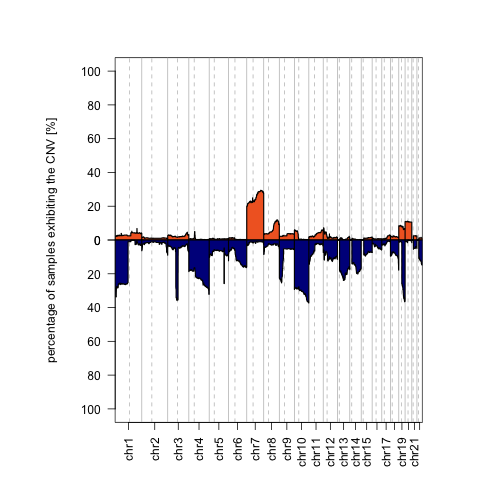

In [6]:
%%R
CNV.summaryplot(segment)

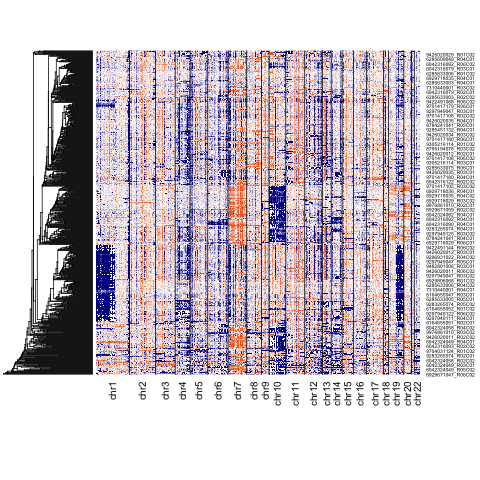

In [7]:
%%R
CNV.heatmap(segment)

In [ ]:
%%R
# Load the RDS file
cnv_data <- readRDS("/Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/CNV_final_results/CNV_detail_results.rds")


In [ ]:
%%R
# Load required libraries
library(dplyr)
library(tidyr)

# Convert the list of data frames into one long data frame
cnv_long <- bind_rows(cnv_data, .id = "Sample") %>%
  select(Sample, Name, Value)

# Reshape to wide format: Samples as rows, Genes as columns
cnv_wide <- cnv_long %>%
  pivot_wider(names_from = Name, values_from = Value)

# View the first few rows
head(cnv_wide)

# Check structure
str(cnv_wide)


tibble [689 × 21] (S3: tbl_df/tbl/data.frame)
 $ Sample  : chr [1:689] "6042316060_R01C01" "6042316060_R01C02" "6042316060_R02C01" "6042316060_R02C02" ...
 $ MCL1    : num [1:689] 0.082 0.07 0.11 0.035 0.013 0.025 0.05 0.08 0.061 0.105 ...
 $ MYCN    : num [1:689] 0.253 0.037 0.099 0.049 0.09 0.091 -0.093 0.088 0.04 0.032 ...
 $ GLI2    : num [1:689] -0.004 0.002 0.003 -0.034 0.023 0.042 -0.018 0.007 0.002 -0.025 ...
 $ EGFR    : num [1:689] 0.212 -0.098 -0.024 -0.089 -0.042 0.061 -0.073 -0.075 0.917 0.172 ...
 $ CDK6    : num [1:689] 0.249 -0.013 0.29 0.26 0.053 0.166 -0.045 0.005 -0.05 0.261 ...
 $ MET     : num [1:689] 0.301 -0.104 0.186 0.279 -0.035 0.178 0.044 -0.005 0.006 0.242 ...
 $ FGFR1   : num [1:689] 0.17 0.036 0.001 0.027 -0.069 0.012 0.016 0.018 0.018 0.012 ...
 $ MYC     : num [1:689] 0.245 0.17 0.127 0.051 0.037 0.072 0.198 0.061 0.081 0.046 ...
 $ CDKN2A/B: num [1:689] -0.158 0.086 0.162 0.093 -0.859 0.023 0.184 -0.031 -0.836 0.07 ...
 $ PTCH1   : num [1:689] 0.013 -0.

In [ ]:
%%R

sample_sheet <- read.csv("/Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/Sample_Sheet.csv", stringsAsFactors = FALSE)

sample_sheet_selected <- sample_sheet %>%
  select(Combined, Sample_Name)

cnv_final <- cnv_wide %>%
  left_join(sample_sheet_selected, by = c("Sample" = "Combined")) %>%
  distinct(Sample, .keep_all = TRUE)  # Remove duplicate rows, keeping the first occurrence

head(cnv_final)
str(cnv_final)


tibble [689 × 22] (S3: tbl_df/tbl/data.frame)
 $ Sample     : chr [1:689] "6042316060_R01C01" "6042316060_R01C02" "6042316060_R02C01" "6042316060_R02C02" ...
 $ MCL1       : num [1:689] 0.082 0.07 0.11 0.035 0.013 0.025 0.05 0.08 0.061 0.105 ...
 $ MYCN       : num [1:689] 0.253 0.037 0.099 0.049 0.09 0.091 -0.093 0.088 0.04 0.032 ...
 $ GLI2       : num [1:689] -0.004 0.002 0.003 -0.034 0.023 0.042 -0.018 0.007 0.002 -0.025 ...
 $ EGFR       : num [1:689] 0.212 -0.098 -0.024 -0.089 -0.042 0.061 -0.073 -0.075 0.917 0.172 ...
 $ CDK6       : num [1:689] 0.249 -0.013 0.29 0.26 0.053 0.166 -0.045 0.005 -0.05 0.261 ...
 $ MET        : num [1:689] 0.301 -0.104 0.186 0.279 -0.035 0.178 0.044 -0.005 0.006 0.242 ...
 $ FGFR1      : num [1:689] 0.17 0.036 0.001 0.027 -0.069 0.012 0.016 0.018 0.018 0.012 ...
 $ MYC        : num [1:689] 0.245 0.17 0.127 0.051 0.037 0.072 0.198 0.061 0.081 0.046 ...
 $ CDKN2A/B   : num [1:689] -0.158 0.086 0.162 0.093 -0.859 0.023 0.184 -0.031 -0.836 0.07 ...
 $ P

In [ ]:
%%R
# Save cnv_final without the 'Sample' column
write.csv(cnv_final %>% select(-Sample), 
          "/Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/CNV_final_results/cnv_final.csv", 
          row.names = FALSE)


In [ ]:
%%R

library(dplyr)


input_file <- "/Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/CNV_final_results/cnv_final.csv"
output_file <- "/Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/CNV_final_results/cnv_final_cleaned.csv"


cnv_data <- read.csv(input_file, stringsAsFactors = FALSE)
cnv_cleaned <- cnv_data %>%
  filter(!is.na(Sample_Name))

write.csv(cnv_cleaned, output_file, row.names = FALSE)

cat("File saved as:", output_file, "\n")


File saved as: /Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/CNV_final_results/cnv_final_cleaned.csv 


In [ ]:
%%R
df=read.csv("/Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/CNV_final_results/cnv_final_cleaned.csv")
nrow(df)

[1] 656
